<a href="https://colab.research.google.com/github/SkyFlowTraveler/AmesHousingPrice-regression/blob/main/AmesHousingRegTraining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import fetch_openml

ames = fetch_openml(
    name = 'house_prices',
    as_frame = True
)

X = ames.data
y = ames.target

In [ ]:
X.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Shed,350,11,2009,WD,Normal
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,1,2008,WD,Normal


In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
X.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000


In [ ]:
X.iloc[:, 78].value_counts() #здесь я смотрел распределение признаков по категориям и редкость тех или иных, и смотрел какой encoding применять

,count
SaleType,
WD,1267
New,122
COD,43
ConLD,9
ConLI,5
ConLw,5
CWD,4
Oth,3
Con,2


In [ ]:
!pip install xgboost

In [ ]:
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin


class FeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Drop
        drop_cols = [
            "Id", "Utilities", "Condition2", "RoofStyle", "RoofMatl",
            "Heating", "LowQualFinSF", "MiscFeature"
        ]
        X = X.drop(columns=[c for c in drop_cols if c in X.columns], errors="ignore")

        # Time features
        X["HouseAge"] = X["YrSold"] - X["YearBuilt"]
        X["AgeFromRemod"] = X["YrSold"] - X["YearRemodAdd"]

        # Garage
        X["GarageYrBlt"] = X["GarageYrBlt"].fillna(X["YearBuilt"])
        X["GarageAge"] = X["YrSold"] - X["GarageYrBlt"]
        X["GarageIsNew"] = (X["GarageYrBlt"] == X["YearBuilt"]).astype(int)

        # Basement
        X["HasBsmtFin"] = (X["BsmtFinSF1"] > 0).astype(int)
        X["BsmtFinRatio"] = (X["BsmtFinSF1"] + X["BsmtFinSF2"]) / (X["TotalBsmtSF"] + 1)

        # Area
        X["TotalSF"] = X["TotalBsmtSF"] + X["1stFlrSF"] + X["2ndFlrSF"]
        X["GrLivArea"] = np.log1p(X["GrLivArea"])
        X["LotArea"] = np.log1p(X["LotArea"])
        X["MiscVal"] = np.log1p(X["MiscVal"])

        # Baths
        X["TotalBath"] = (
            X["FullBath"] + 0.5 * X["HalfBath"]
            + X["BsmtFullBath"] + 0.5 * X["BsmtHalfBath"]
        )

        # Kitchen
        X["HasMultipleKitchens"] = (X["KitchenAbvGr"] > 1).astype(int)

        # Rooms
        X["AvgRoomSize"] = X["GrLivArea"] / (X["TotRmsAbvGrd"] + 1)

        # Cyclical month
        X["MoSold_sin"] = np.sin(2 * np.pi * X["MoSold"] / 12)
        X["MoSold_cos"] = np.cos(2 * np.pi * X["MoSold"] / 12)

        return X

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

ordinal_features = [
    "LotShape", "LandSlope", "HouseStyle", "ExterQual", "ExterCond",
    "Foundation", "BsmtQual", "BsmtCond", "BsmtExposure",
    "BsmtFinType1", "BsmtFinType2", "HeatingQC",
    "KitchenQual", "Functional", "FireplaceQu",
    "GarageFinish", "GarageQual", "GarageCond",
    "PavedDrive", "PoolQC"
]

ordinal_categories = [
    ["Reg", "IR1", "IR2", "IR3"],                       # LotShape
    ["Gtl", "Mod", "Sev"],                             # LandSlope
    ["1Story", "1.5Fin", "1.5Unf", "2Story", "2.5Fin", "2.5Unf", "SFoyer", "SLvl"],

    ["Po", "Fa", "TA", "Gd", "Ex"],                    # ExterQual
    ["Po", "Fa", "TA", "Gd", "Ex"],

    ["Slab", "BrkTil", "CBlock", "PConc", "Wood"],     # Foundation (примерно упорядочено)

    ["None", "Po", "Fa", "TA", "Gd", "Ex"],            # BsmtQual
    ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    ["None", "No", "Mn", "Av", "Gd"],

    ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    ["None", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],

    ["Po", "Fa", "TA", "Gd", "Ex"],

    ["Po", "Fa", "TA", "Gd", "Ex"],                    # KitchenQual

    ["Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"],

    ["NoFireplace", "Po", "Fa", "TA", "Gd", "Ex"],

    ["NoGarage", "Unf", "RFn", "Fin"],

    ["NoGarage", "Po", "Fa", "TA", "Gd", "Ex"],
    ["NoGarage", "Po", "Fa", "TA", "Gd", "Ex"],

    ["N", "P", "Y"],

    ["NoPool", "Fa", "TA", "Gd", "Ex"]
]

numeric_features = [
    "OverallQual", "OverallCond", "GarageCars", "GarageArea",
    "TotalSF", "TotalBath", "HouseAge", "AgeFromRemod",
    "GarageAge", "AvgRoomSize", "BsmtFinRatio"
]

onehot_features = [
    "MSSubClass", "LotConfig", "Condition1",
    "BldgType", "MasVnrType", "GarageType",
    "SaleType"
]

label_features = ["Street", "CentralAir"]


preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),

        ("ord", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
            ("encoder", OrdinalEncoder(
                categories=ordinal_categories,
                handle_unknown='use_encoded_value',
                unknown_value=-1
            ))
        ]), ordinal_features),

        ("cat", OneHotEncoder(handle_unknown="ignore"), onehot_features),

        ("label", OrdinalEncoder(
            handle_unknown='use_encoded_value',
            unknown_value=-1
        ), label_features),
    ],
    remainder="drop"
)

In [ ]:
!pip install lightgbm

In [ ]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import xgboost as xgb
import lightgbm as lgb

models = {
    "Lasso": Lasso(alpha=0.001, random_state=42),
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "SVR_linear": SVR(kernel='linear', C=1.0),
    "SVR_rbf": SVR(kernel='rbf', C=1.0, gamma='scale'),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=200, random_state=42),
    "XGBoost": xgb.XGBRegressor(n_estimators=200, random_state=42, eval_metric='rmse'),
    "LightGBM": lgb.LGBMRegressor(n_estimators=200, random_state=42)
}

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.574e+11, tolerance: 7.592e+08
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.955e+11, tolerance: 7.288e+08
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.334e+11, tolerance: 6.990e

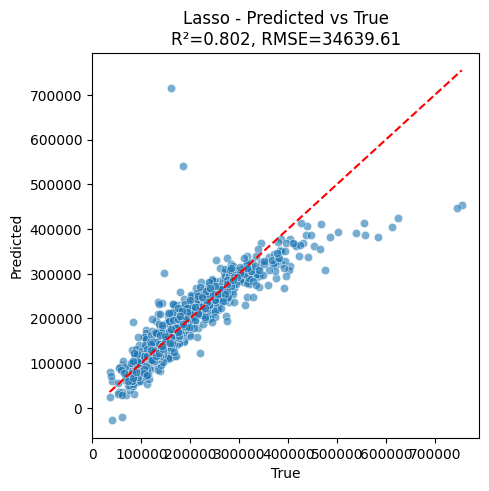

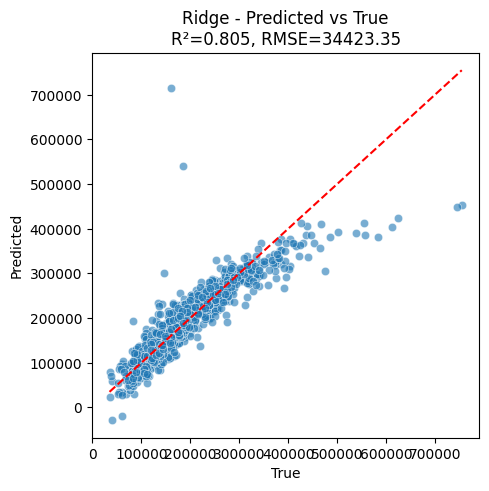

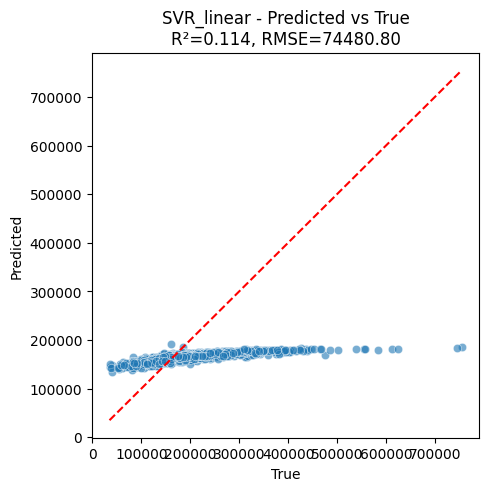

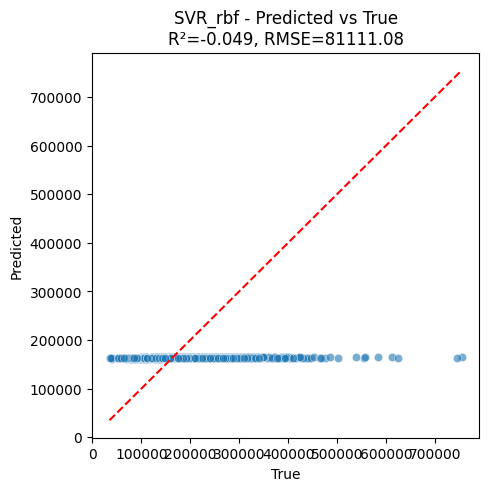

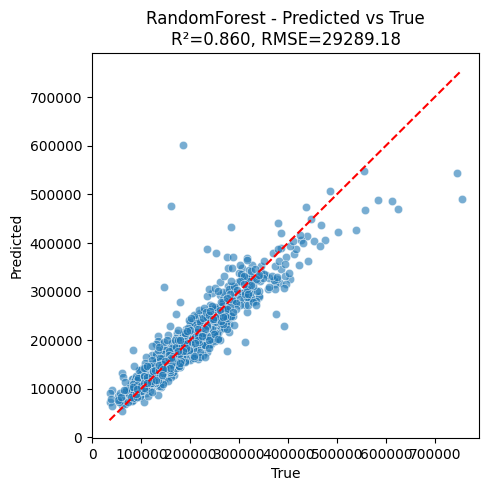

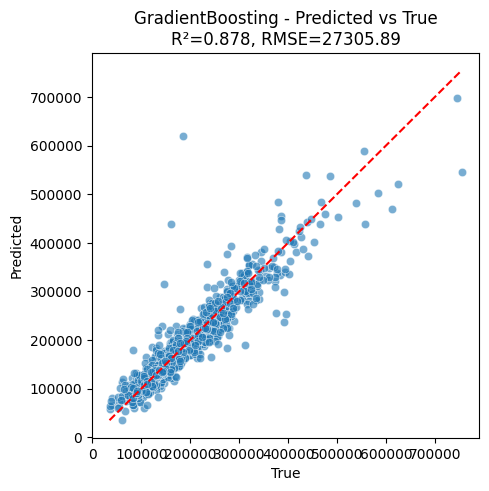

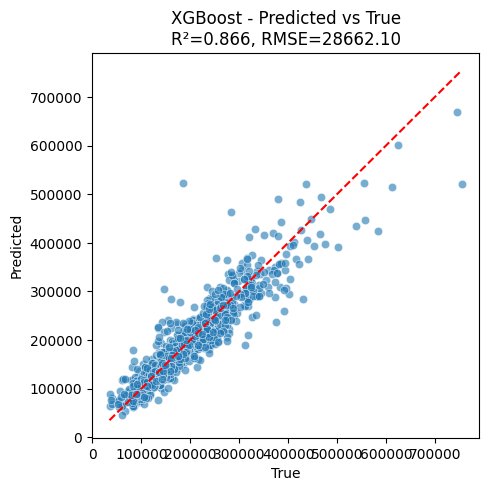

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000265 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1483
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 64
[LightGBM] [Info] Start training from score 180717.091610
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000236 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1484
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 64
[LightGBM] [Info] Start training from score 180407.575342


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000246 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1480
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 64
[LightGBM] [Info] Start training from score 180007.375000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000249 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1486
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 63
[LightGBM] [Info] Start training from score 182883.660103


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000460 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1483
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 64
[LightGBM] [Info] Start training from score 180590.277397
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000254 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1483
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 64
[LightGBM] [Info] Start training from score 180717.091610


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000253 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1484
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 64
[LightGBM] [Info] Start training from score 180407.575342
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000424 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1480
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 64
[LightGBM] [Info] Start training from score 180007.375000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000258 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1486
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 63
[LightGBM] [Info] Start training from score 182883.660103
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000235 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1483
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 64
[LightGBM] [Info] Start training from score 180590.277397


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


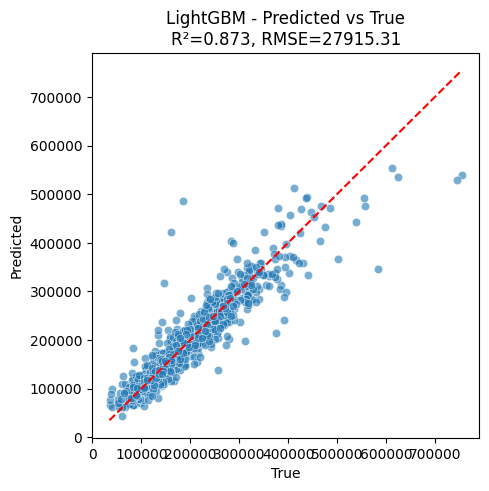

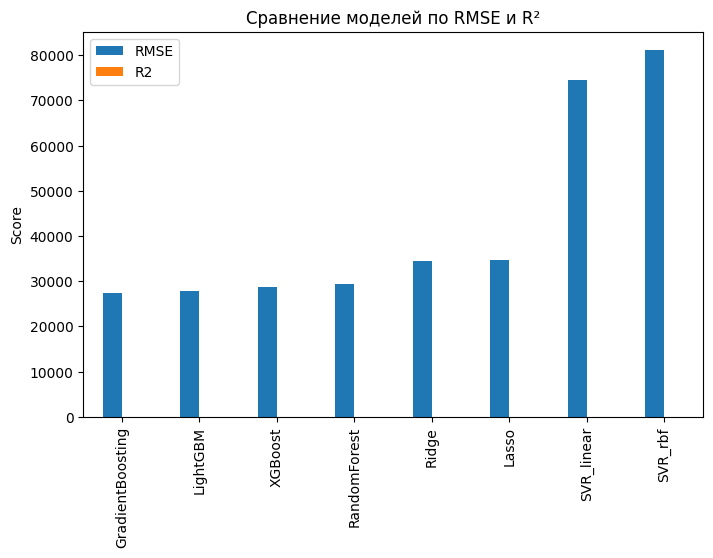

Lasso: RMSE = 34639.6073, R² = 0.8023
Ridge: RMSE = 34423.3494, R² = 0.8045
SVR_linear: RMSE = 74480.8049, R² = 0.1145
SVR_rbf: RMSE = 81111.0758, R² = -0.0492
RandomForest: RMSE = 29289.1763, R² = 0.8599
GradientBoosting: RMSE = 27305.8862, R² = 0.8781
XGBoost: RMSE = 28662.0984, R² = 0.8663
LightGBM: RMSE = 27915.3056, R² = 0.8726


In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

r2_results = {}

# Вычисляем R² и scatterplot предсказания для каждой модели
for name, model in models.items():
    pipe = Pipeline([
        ("feature_engineering", FeatureEngineer()),
        ("preprocessing", preprocessor),
        ("model", model)
    ])

    # Кросс-валидация RMSE
    scores = cross_val_score(
        pipe,
        X,
        y,
        cv=5,
        scoring="neg_root_mean_squared_error"
    )
    rmse = -scores.mean()
    results[name] = rmse

    # Кросс-валидация R²
    y_pred = cross_val_predict(pipe, X, y, cv=5)
    r2 = r2_score(y, y_pred)
    r2_results[name] = r2

    # Scatter plot
    plt.figure(figsize=(5,5))
    sns.scatterplot(x=y, y=y_pred, alpha=0.6)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # y=x линия
    plt.title(f"{name} - Predicted vs True\nR²={r2:.3f}, RMSE={rmse:.2f}")
    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.show()

# Barplot сравнения моделей
metrics_df = pd.DataFrame({
    "RMSE": results,
    "R2": r2_results
})

metrics_df.sort_values("RMSE", inplace=True)
metrics_df.plot(kind="bar", figsize=(8,5))
plt.title("Сравнение моделей по RMSE и R²")
plt.ylabel("Score")
plt.show()

# Печать значений
for k in results:
    print(f"{k}: RMSE = {results[k]:.4f}, R² = {r2_results[k]:.4f}")

# Попробуем CatBoost на почти сырых данных

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 4.4 MB/s eta 0:00:00


In [ ]:
# Сначала делаем копию, чтобы не менять оригинальные X
X_cb = X_feat.copy()

# Категориальные признаки
categorical_features = X_cb.select_dtypes(include=['object']).columns.tolist()

# Преобразуем NaN в строку 'NA' для категориальных
for col in categorical_features:
    X_cb[col] = X_cb[col].fillna("NA").astype(str)

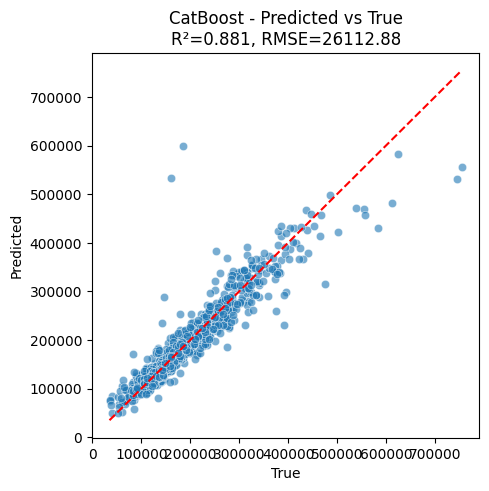

CatBoost: RMSE = 26112.8805, R² = 0.8806


In [ ]:
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Категориальные признаки
categorical_features = X_feat.select_dtypes(include=['object']).columns.tolist()

# Копия данных для CatBoost с обработкой NaN
X_cb = X_feat.copy()
for col in categorical_features:
    X_cb[col] = X_cb[col].fillna("NA").astype(str)

# KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

y_pred = np.zeros(len(y))
rmse_scores = []
r2_scores = []

for train_idx, test_idx in kf.split(X_cb):
    X_train, X_test = X_cb.iloc[train_idx], X_cb.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = CatBoostRegressor(
        verbose=0,
        random_state=42,
        loss_function='RMSE'
    )

    model.fit(X_train, y_train, cat_features=categorical_features)

    y_pred_fold = model.predict(X_test)
    y_pred[test_idx] = y_pred_fold

    # RMSE вручную через sqrt
    rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred_fold)))
    r2_scores.append(r2_score(y_test, y_pred_fold))

# Итоговые метрики
rmse_mean = np.mean(rmse_scores)
r2_mean = np.mean(r2_scores)

# Scatterplot
plt.figure(figsize=(5,5))
sns.scatterplot(x=y, y=y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.title(f"CatBoost - Predicted vs True\nR²={r2_mean:.3f}, RMSE={rmse_mean:.2f}")
plt.xlabel("True")
plt.ylabel("Predicted")
plt.show()

print(f"CatBoost: RMSE = {rmse_mean:.4f}, R² = {r2_mean:.4f}")

## Посмотрим важность признаков с точки зрения использования в деревьях

        Feature  Importance
78      TotalSF   19.983260
14  OverallQual   16.178942
39    GrLivArea    5.344098
46  KitchenQual    3.825359
3       LotArea    3.245779
25     BsmtQual    2.697202
29   BsmtFinSF1    2.663018
37     1stFlrSF    2.628443
22    ExterQual    2.607428
79    TotalBath    2.340271


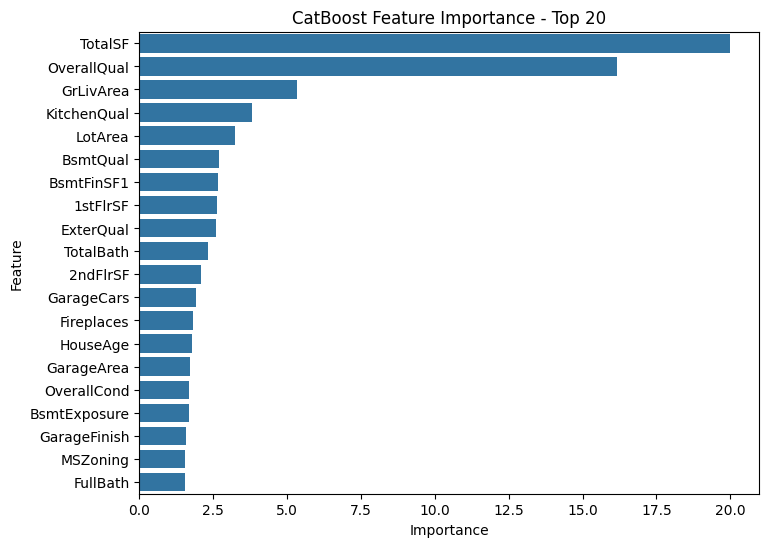

In [ ]:
# Обучаем CatBoost на всей выборке, чтобы получить feature importance
final_model = CatBoostRegressor(
    verbose=0,
    random_state=42,
    loss_function='RMSE'
)
final_model.fit(X_cb, y, cat_features=categorical_features)

# Получаем важность признаков
importances = final_model.get_feature_importance()
feature_names = X_cb.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Печатаем топ-10
print(importance_df.head(10))

# Barplot топ-20 признаков
plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20))
plt.title("CatBoost Feature Importance - Top 20")
plt.show()

# Теперь поэксперементируем с PCA

Original features: 37, PCA components: 27
                          RMSE        R2
Ridge             38784.429029  0.732415
Lasso             38788.797542  0.732316
RandomForest      32567.932600  0.818263
GradientBoosting  31558.712473  0.823296


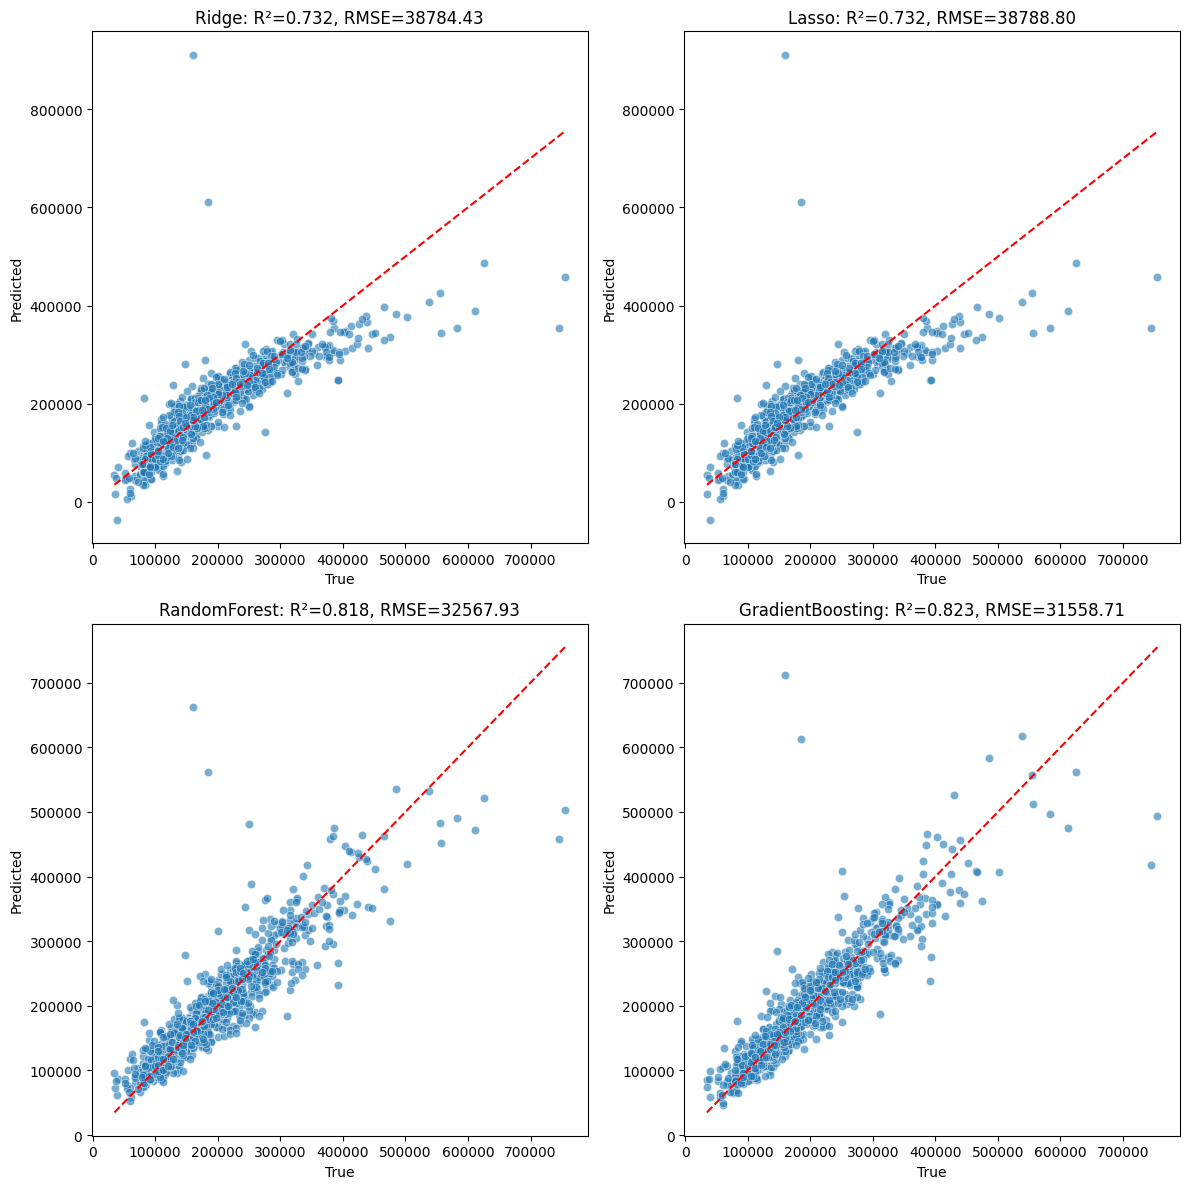

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. Числовые признаки
num_cols = X.select_dtypes(include=['int64','float64']).columns
X_num = X[num_cols]

# 2. Импутация пропусков
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X_num)

# 3. Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# 4. PCA
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"Original features: {X_num.shape[1]}, PCA components: {X_pca.shape[1]}")

# 5. Модели
models = {
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "Lasso": Lasso(alpha=0.001, random_state=42, max_iter=5000),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=200, random_state=42)
}

# 6. KFold CV и оценка
kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = {}
y_preds = {}

for name, model in models.items():
    y_pred = np.zeros(len(y))
    rmse_scores = []
    r2_scores = []

    for train_idx, test_idx in kf.split(X_pca):
        X_train, X_test = X_pca[train_idx], X_pca[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        y_pred_fold = model.predict(X_test)
        y_pred[test_idx] = y_pred_fold

        rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred_fold)))
        r2_scores.append(r2_score(y_test, y_pred_fold))

    results[name] = {"RMSE": np.mean(rmse_scores), "R2": np.mean(r2_scores)}
    y_preds[name] = y_pred

# 7. Вывод результатов
results_df = pd.DataFrame(results).T
print(results_df)

# 8. Scatterplots для всех моделей
plt.figure(figsize=(12,12))
for i, (name, y_pred) in enumerate(y_preds.items(), 1):
    plt.subplot(2,2,i)
    sns.scatterplot(x=y, y=y_pred, alpha=0.6)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
    plt.title(f"{name}: R²={results[name]['R2']:.3f}, RMSE={results[name]['RMSE']:.2f}")
    plt.xlabel("True")
    plt.ylabel("Predicted")
plt.tight_layout()
plt.show()

 ### PCA, не особо улучшил результат. Я считаю из-за хорошей работы с генерацией признаков и большого количества важных категориальных признаков, в то время как PCA работает только с численными

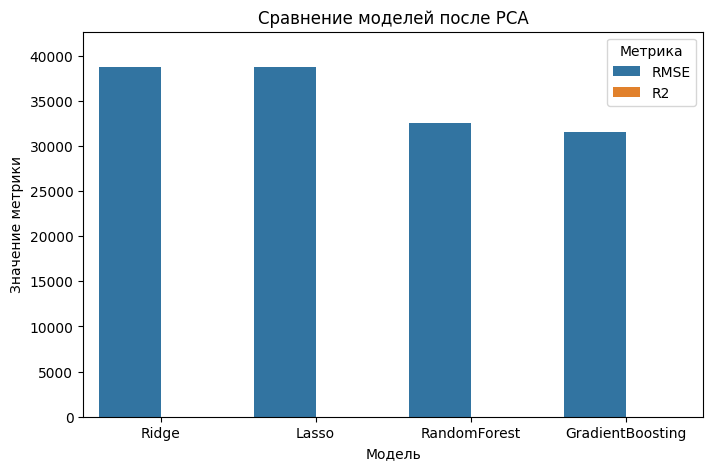

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Подготовка данных для barplot
metrics_df = results_df.reset_index().melt(id_vars='index', var_name='Metric', value_name='Value')
metrics_df.rename(columns={'index': 'Model'}, inplace=True)

# Barplot
plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='Value', hue='Metric', data=metrics_df)
plt.title("Сравнение моделей после PCA")
plt.ylabel("Значение метрики")
plt.xlabel("Модель")
plt.ylim(0, max(metrics_df['Value'])*1.1)  # немного выше для визуала
plt.legend(title='Метрика')
plt.show()